## Import Package

In [ ]:
import time
import math
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, Subset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
torch.manual_seed(2025)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Current Device : {device}')

Current Device : cuda


## Prepare Dataset

### Get All Training Image

In [ ]:
img_names = glob.glob("/content/DOG_BREED_IDENTIFICATION/train/*.jpg")

print(f'Total images in Dataset : {len(img_names)}')

Total images in Dataset : 10222


### Create Custom Dataset

In [ ]:
class DogDataset(Dataset):

  def __init__(self, img_path, csv_path):
    self.csv_path = csv_path
    self.transform = None

    self.img_names = glob.glob(f"{img_path}/*.jpg")

    if csv_path:
      label_df = pd.read_csv(csv_path)
      self.label_idx2name = label_df['breed'].unique()
      self.label_name2idx = {}
      for i in range(len(self.label_idx2name)):
        self.label_name2idx[self.label_idx2name[i]] = i
      self.img2label = {}
      for _, row in label_df.iterrows():
        self.img2label[f"{img_path}/{row['id']}.jpg"] = self.label_name2idx[row['breed']]

  def __len__(self):
    return len(self.img_names)

  def __getitem__(self, index):
    img = self.img_names[index]

    if self.csv_path:
      label = self.img2label[img]
      label = torch.tensor(label)
    else:
      label = -1

    img = Image.open(img).convert("RGB")
    img = self.transform(img)
    return (img, label)

In [ ]:
channel_mean = torch.Tensor([0.485, 0.456, 0.406])
channel_std = torch.Tensor([0.229, 0.224, 0.225])

vit_train_transform_fn = transforms.Compose([
  transforms.Resize(256),
  transforms.CenterCrop(224),

  transforms.RandomHorizontalFlip(p=0.6),
  transforms.RandomRotation(degrees=(30)),

  transforms.ToTensor(),
  transforms.Normalize(mean=channel_mean, std=channel_std),
])

vit_valid_transform_fn = transforms.Compose([
  transforms.Resize(256),
  transforms.CenterCrop(224),
  transforms.ToTensor(),
  transforms.Normalize(mean=channel_mean, std=channel_std),
])

In [ ]:
dataset = DogDataset(
  img_path='/content/DOG_BREED_IDENTIFICATION/train',
  csv_path='/content/DOG_BREED_IDENTIFICATION/labels.csv',
)

### Split `dataset` into `train_dataset` and `valid_dataset`

In [ ]:
indexes = list(range(len(dataset)))
train_indexes, valid_indexes = train_test_split(indexes, test_size=0.1)
train_dataset = Subset(dataset, train_indexes)
valid_dataset = Subset(dataset, valid_indexes)

print(f"Number of samples in train_dataset: {len(train_dataset)}")
print(f"Number of samples in valid_dataset: {len(valid_dataset)}")

Number of samples in train_dataset: 9199
Number of samples in valid_dataset: 1023


In [ ]:
dataset.transform = vit_train_transform_fn
train_dataset.transform = vit_train_transform_fn
valid_dataset.transform = vit_valid_transform_fn

### Create DataLoader

In [ ]:
train_valid_dataloader = DataLoader(
  dataset,
  batch_size=8,
  shuffle=True
)

train_dataloader = DataLoader(
  train_dataset,
  batch_size=8,
  shuffle=True
)

valid_dataloader = DataLoader(
  valid_dataset,
  batch_size=32,
  shuffle=True
)

## Build Model

In [ ]:
class PretrainViT(nn.Module):

  def __init__(self):
    super(PretrainViT, self).__init__()
    model = models.vit_l_16(pretrained=True)
    num_classifier_feature = model.heads.head.in_features
    model.heads.head = nn.Sequential(
      nn.Linear(num_classifier_feature, 120)
    )
    self.model = model

    for param in self.model.named_parameters():
      if "heads" not in param[0]:
        param[1].requires_grad = False

  def forward(self, x):
    return self.model(x)

In [ ]:
net = PretrainViT()
net.to(device)

## Train Model

### Loss Function and Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.009, momentum=0.9)

### Training Loop

In [ ]:
def get_accuracy(output, label):
  output = output.to("cpu")
  label = label.to("cpu")

  sm = F.softmax(output, dim=1)
  _, index = torch.max(sm, dim=1)
  return torch.sum((label == index)) / label.size()[0]

In [ ]:
def train(model, dataloader):
  model.train()
  running_loss = 0.0
  total_loss = 0.0
  running_acc = 0.0
  total_acc = 0.0

  for batch_idx, (batch_img, batch_label) in enumerate(dataloader):

    batch_img = batch_img.to(device)
    batch_label = batch_label.to(device)

    optimizer.zero_grad()
    output = net(batch_img)
    loss = criterion(output, batch_label)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    total_loss += loss.item()

    acc = get_accuracy(output, batch_label)
    running_acc += acc
    total_acc += acc

    if batch_idx % 100 == 0 and batch_idx != 0:
      print(f"[step: {batch_idx:4d}/{len(dataloader)}] loss: {running_loss / 100:.3f}")
      running_loss = 0.0
      running_acc = 0.0

  return total_loss / len(dataloader), total_acc / len(dataloader)

In [ ]:
def validate(model, dataloader):
  model.eval()
  total_loss = 0.0
  total_acc = 0.0

  for batch_idx, (batch_img, batch_label) in enumerate(dataloader):

    batch_img = batch_img.to(device)
    batch_label = batch_label.to(device)

    # optimizer.zero_grad()
    output = net(batch_img)
    loss = criterion(output, batch_label)
    # loss.backward()
    # optimizer.step()

    total_loss += loss.item()
    acc = get_accuracy(output, batch_label)
    total_acc += acc

  return total_loss / len(dataloader), total_acc / len(dataloader)

In [ ]:
EPOCHS = 7
train_loss_history = []
valid_loss_history = []

train_acc_history = []
valid_acc_history = []

for epoch in range(EPOCHS):
  train_loss, train_acc = train(net, train_dataloader)
  valid_loss, valid_acc = validate(net, valid_dataloader)
  print(f"Epoch: {epoch:2d}, training loss: {train_loss:.3f}, training acc: {train_acc:.3f} validation loss: {valid_loss:.3f}, validation acc: {valid_acc:.3f}")

  train_loss_history.append(train_loss)
  valid_loss_history.append(valid_loss)

  train_acc_history.append(train_acc)
  valid_acc_history.append(valid_acc)

  if valid_loss <= min(valid_loss_history):
    torch.save(net.state_dict(), "/content/drive/MyDrive/DOG_BREED_IDENTIFICATION/models1/net.pt")

[step:  100/1150] loss: 2.528
[step:  200/1150] loss: 0.445
[step:  300/1150] loss: 0.277
[step:  400/1150] loss: 0.185
[step:  500/1150] loss: 0.209
[step:  600/1150] loss: 0.172
[step:  700/1150] loss: 0.182
[step:  800/1150] loss: 0.141
[step:  900/1150] loss: 0.110
[step: 1000/1150] loss: 0.139
[step: 1100/1150] loss: 0.110
Epoch:  0, training loss: 0.398, training acc: 0.922 validation loss: 0.120, validation acc: 0.970
[step:  100/1150] loss: 0.074
[step:  200/1150] loss: 0.078
[step:  300/1150] loss: 0.082
[step:  400/1150] loss: 0.086
[step:  500/1150] loss: 0.082
[step:  600/1150] loss: 0.088
[step:  700/1150] loss: 0.105
[step:  800/1150] loss: 0.100
[step:  900/1150] loss: 0.092
[step: 1000/1150] loss: 0.093
[step: 1100/1150] loss: 0.087
Epoch:  1, training loss: 0.088, training acc: 0.975 validation loss: 0.115, validation acc: 0.968
[step:  100/1150] loss: 0.062
[step:  200/1150] loss: 0.046
[step:  300/1150] loss: 0.069
[step:  400/1150] loss: 0.061
[step:  500/1150] loss

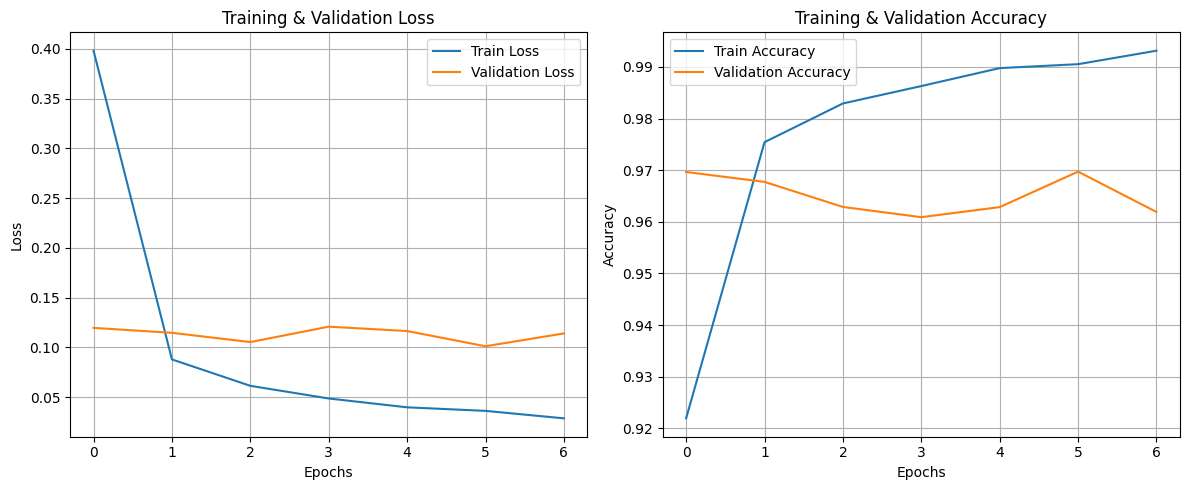

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label="Train Loss")
plt.plot(valid_loss_history, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(valid_acc_history, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
torch.save(net.state_dict(), "/content/drive/MyDrive/DOG_BREED_IDENTIFICATION/models1/net_state_dict.pt")
torch.save(net, "/content/drive/MyDrive/DOG_BREED_IDENTIFICATION/models1/net_full_model.pt")

In [ ]:
net = torch.load("/content/drive/MyDrive/DOG_BREED_IDENTIFICATION/models1/net_full_model.pt")
net.to(device)
net.eval()

In [ ]:
all_preds = []
all_labels = []

total_inference_time = 0.0
total_samples = 0

with torch.no_grad():
  for batch_idx, (batch_img, batch_label) in enumerate(valid_dataloader):
    batch_img, batch_label = batch_img.to(device), batch_label.to(device)

    start_time = time.time()

    outputs = net(batch_img)
    _, preds = torch.max(outputs, 1)

    end_time = time.time()

    total_inference_time += (end_time - start_time)
    total_samples += batch_img.size(0)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(batch_label.cpu().numpy())

avg_inference_time = total_inference_time / total_samples

Accuracy: 0.9629
Precision: 0.9685
Recall: 0.9629
F1 Score: 0.9632
Average Inference Time per Sample: 0.001647 seconds


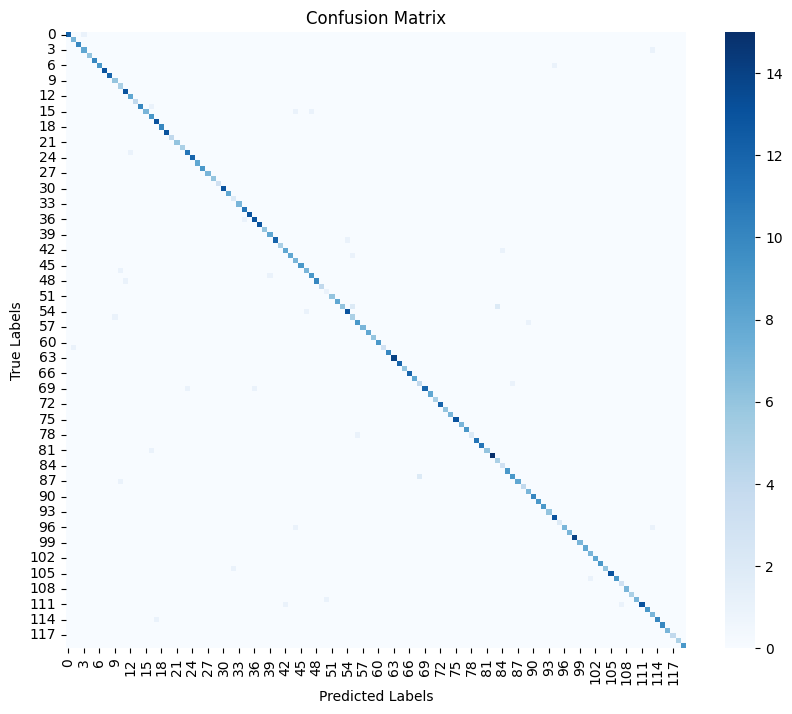

In [ ]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')
conf_matrix = confusion_matrix(all_labels, all_preds)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Average Inference Time per Sample: {avg_inference_time:.6f} seconds")

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=False, fmt='d', cmap='Blues')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()